# 02 — Temporal Difference Learning
**Week 5 | Model-Free Learning**

TD learning **bootstraps** — it updates estimates using other estimates, without waiting for the episode to end.

**TD(0) update rule:**

$$V(s_t) \leftarrow V(s_t) + \alpha \left[ \underbrace{R_{t+1} + \gamma V(s_{t+1})}_{\text{TD target}} - V(s_t) \right]$$

The term in brackets is called the **TD error** δ_t.  
MC waits until the end of the episode. TD can learn after every single step.

In [8]:
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys; subprocess.check_call([sys.executable,'-m','pip','install','gymnasium','-q']); import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

env = gym.make('FrozenLake-v1', is_slippery=True)
n_s = env.observation_space.n; n_a = env.action_space.n

## 1. TD(0) Prediction

In [9]:
def td0_prediction(env, policy_fn, n_episodes=30_000, alpha=0.1, gamma=0.99):
    V = np.zeros(n_s)
    td_errors_per_ep = []
    for _ in range(n_episodes):
        s, _ = env.reset()
        ep_errors = []
        done = False
        while not done:
            a = policy_fn(s)
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            td_target = r + gamma * V[ns] * (not done)
            td_error  = td_target - V[s]
            V[s]     += alpha * td_error
            ep_errors.append(abs(td_error))
            s = ns
        td_errors_per_ep.append(np.mean(ep_errors))
    return V, td_errors_per_ep

random_policy = lambda s: env.action_space.sample()
print("Running TD(0) prediction...")
V_td, td_errors = td0_prediction(env, random_policy)

Running TD(0) prediction...


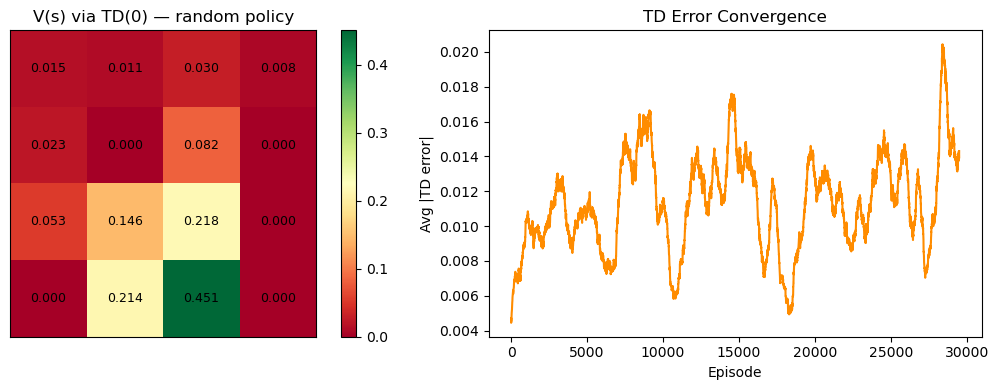

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(V_td.reshape(4,4), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for s in range(16):
    r,c=divmod(s,4); axes[0].text(c,r,f'{V_td[s]:.3f}',ha='center',va='center',fontsize=9)
axes[0].set_title('V(s) via TD(0) — random policy'); axes[0].set_xticks([]); axes[0].set_yticks([])

window=500
rolling_err = np.convolve(td_errors, np.ones(window)/window, mode='valid')
axes[1].plot(rolling_err, color='darkorange', linewidth=1.5)
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Avg |TD error|')
axes[1].set_title('TD Error Convergence')
plt.tight_layout(); plt.show()

## 2. MC vs TD — Side-by-Side Comparison
Classic example from Sutton & Barto: the 5-state random walk.

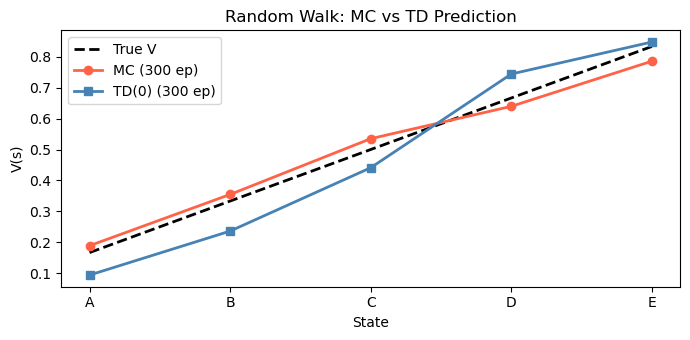

MC  RMS error: 0.0322
TD  RMS error: 0.0699


In [11]:
# 5-state random walk: states 0-6, states 0 and 6 are terminal
# Reward: +1 at state 6, 0 elsewhere
# True values: V(1)=1/6, V(2)=2/6, V(3)=3/6, V(4)=4/6, V(5)=5/6
true_V = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 0])

class RandomWalkEnv:
    def reset(self): self.s=3; return self.s
    def step(self, a=None):
        self.s += np.random.choice([-1,1])
        done = self.s in [0,6]
        r = 1.0 if self.s==6 else 0.0
        return self.s, r, done

def mc_prediction_rw(n_episodes=300, gamma=1.0):
    V = np.full(7, 0.5); V[0]=V[6]=0
    for _ in range(n_episodes):
        env_rw = RandomWalkEnv(); s=env_rw.reset()
        episode=[]; done=False
        while not done:
            ns, r, done = env_rw.step()
            episode.append((s,r)); s=ns
        G=0
        for st,rw in reversed(episode):
            G=rw+gamma*G; V[st]+= 0.01*(G-V[st])
    return V

def td_prediction_rw(n_episodes=300, alpha=0.1, gamma=1.0):
    V = np.full(7, 0.5); V[0]=V[6]=0
    for _ in range(n_episodes):
        env_rw = RandomWalkEnv(); s=env_rw.reset(); done=False
        while not done:
            ns,r,done = env_rw.step()
            V[s] += alpha*(r+gamma*V[ns]-V[s]); s=ns
    return V

V_mc_rw = mc_prediction_rw()
V_td_rw = td_prediction_rw()

x = np.arange(1,6)
labels = ['A','B','C','D','E']
plt.figure(figsize=(7,3.5))
plt.plot(x, true_V[1:6], 'k--', linewidth=2, label='True V')
plt.plot(x, V_mc_rw[1:6], 'tomato', marker='o', linewidth=2, label='MC (300 ep)')
plt.plot(x, V_td_rw[1:6], 'steelblue', marker='s', linewidth=2, label='TD(0) (300 ep)')
plt.xticks(x, labels); plt.xlabel('State'); plt.ylabel('V(s)')
plt.title('Random Walk: MC vs TD Prediction')
plt.legend(); plt.tight_layout(); plt.show()
print(f"MC  RMS error: {np.sqrt(np.mean((V_mc_rw[1:6]-true_V[1:6])**2)):.4f}")
print(f"TD  RMS error: {np.sqrt(np.mean((V_td_rw[1:6]-true_V[1:6])**2)):.4f}")

## 3. Effect of Learning Rate α

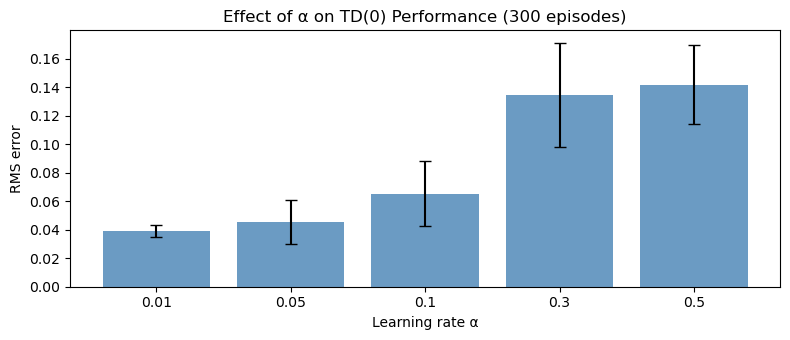

In [12]:
alphas = [0.01, 0.05, 0.1, 0.3, 0.5]
fig, ax = plt.subplots(figsize=(8,3.5))
for alpha in alphas:
    errors=[]
    for _ in range(10):  # average over 10 runs
        V=td_prediction_rw(n_episodes=300, alpha=alpha)
        errors.append(np.sqrt(np.mean((V[1:6]-true_V[1:6])**2)))
    ax.bar(str(alpha), np.mean(errors), yerr=np.std(errors), capsize=4, color='steelblue', alpha=0.8)
ax.set_xlabel('Learning rate α'); ax.set_ylabel('RMS error')
ax.set_title('Effect of α on TD(0) Performance (300 episodes)')
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Increase α to 0.9. What happens to the TD error curve? Does it still converge?
2. Run TD(0) for 1000, 5000, and 10000 episodes. Plot how the estimate of V(3) (centre state) converges to 0.5.
3. **Challenge**: implement **TD(λ)** with eligibility traces. Does λ=0 reproduce TD(0) and λ=1 approximate MC?

Ans 1) Obs - The	α=0.9	error	curve	drops	fast	initially,	then	plateaus
at	a	high,	noisy	level	and	never	comes	down

Running	TD(0)	with	α=0.9...


C:\Users\arinu\AppData\Local\Temp\ipykernel_26448\613415008.py:10: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout();	plt.show()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


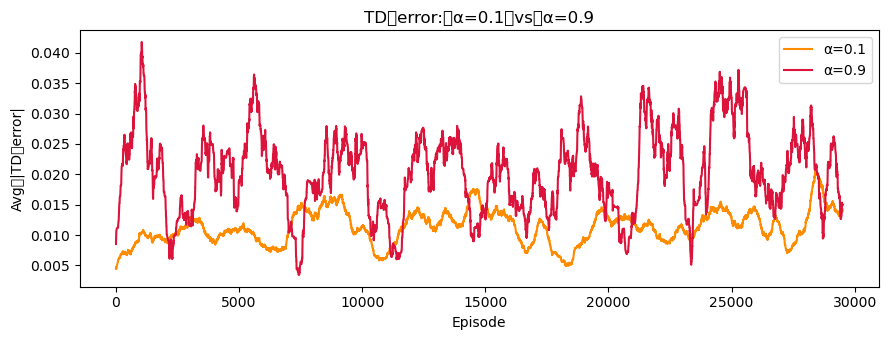

V	at	α=0.9: [[0.001 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.079 0.01  0.001 0.   ]
 [0.    0.091 0.995 0.   ]]


In [13]:
print("Running	TD(0)	with	α=0.9...")
V_td9,	td_errors9	=	td0_prediction(env,	random_policy, n_episodes=30_000,	alpha=0.9)
window	=	500
fig,	ax	=	plt.subplots(figsize=(9,	3.5))
for	errs,	label,	color	in	[(td_errors,	'α=0.1',	'darkorange'),	(td_errors9,	'α=0.9',	'crimson')]:
				ax.plot(np.convolve(errs,	np.ones(window)/window,	mode='valid'),
												label=label,	color=color,	linewidth=1.5)
ax.set_xlabel('Episode');	ax.set_ylabel('Avg	|TD	error|')
ax.set_title('TD	error:	α=0.1	vs	α=0.9');	ax.legend()
plt.tight_layout();	plt.show()
print("V	at	α=0.9:",	np.round(V_td9.reshape(4,4),	3))


Ans 2 (C)	climbs	from	the	0.5	init…	wait	—	it	starts	at	0.5	(the
true	value!)	but	immediately	gets	knocked	around,	then	oscillate

C:\Users\arinu\AppData\Local\Temp\ipykernel_26448\3733204943.py:19: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.legend(fontsize=9);	plt.tight_layout();	plt.show()


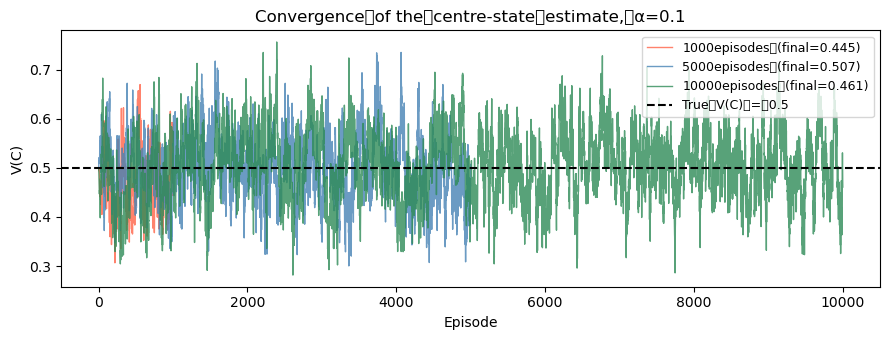

In [14]:
def	td_rw_track_center(n_episodes,	alpha=0.1,	gamma=1.0):
				V	=	np.full(7,	0.5);	V[0]	=	V[6]	=	0
				v3	=	np.zeros(n_episodes)
				for	ep	in	range(n_episodes):
								env_rw	=	RandomWalkEnv();	s	=	env_rw.reset();	done	=	False
								while	not	done:
												ns,	r,	done	=	env_rw.step()
												V[s]	+=	alpha	*	(r	+	gamma	*	V[ns]	-	V[s]);	s	=	ns
								v3[ep]	=	V[3]
				return	v3
plt.figure(figsize=(9,	3.5))
for	n,	color	in	[(1000,	'tomato'),	(5000,	'steelblue'),	(10000,	
'seagreen')]:
				traj	=	td_rw_track_center(n)
				plt.plot(traj,	color=color,	linewidth=1,	alpha=0.8,	label=f'{n}episodes	(final={traj[-1]:.3f})')
plt.axhline(0.5,	color='black',	linestyle='--',	label='True	V(C)	=	0.5')
plt.xlabel('Episode');	plt.ylabel('V(C)')
plt.title('Convergence	of the	centre-state	estimate,	α=0.1')
plt.legend(fontsize=9);	plt.tight_layout();	plt.show()

Ans 3)

In [15]:
def	td_lambda_rw(n_episodes=300,	alpha=0.1,	gamma=1.0,	lam=0.8):
				V	=	np.full(7,	0.5);	V[0]	=	V[6]	=	0
				for	_	in	range(n_episodes):
								env_rw	=	RandomWalkEnv();	s	=	env_rw.reset();	done	=	False
								E	=	np.zeros(7)																														#	eligibility	traces
								while	not	done:
												ns,	r,	done	=	env_rw.step()
												delta	=	r	+	gamma	*	V[ns]	*	(not	done)	-	V[s]
												E[s]	+=	1.0																														#	accumulating	trace
												V	+=	alpha	*	delta	*	E																			#	ALL	eligible	states	updated
												E	*=	gamma	*	lam																									#	decay	traces
												s	=	ns
								V[0]	=	V[6]	=	0
				return	V
lams	=	[0.0,	0.4,	0.8,	1.0]
plt.figure(figsize=(8,	3.5))
plt.plot(np.arange(1,6),	true_V[1:6],	'k--',	linewidth=2,	
label='True	V')
for	lam,	color	in	zip(lams,	
['steelblue','seagreen','darkorange','tomato']):
V	=	np.mean([td_lambda_rw(lam=lam)	for	_	in	range(20)],	axis=0)
rms	=	np.sqrt(np.mean((V[1:6]-true_V[1:6])**2))
plt.plot(np.arange(1,6),	V[1:6],	marker='o',	color=color,	
label=f'λ={lam}	(RMS={rms:.3f})')
plt.xticks(np.arange(1,6),	['A','B','C','D','E'])
plt.legend(fontsize=8);	plt.title('TD(λ)	on	the	5-state	random	walk	(avg	of	20	runs)')
plt.tight_layout();	plt.show()
#	sanity	check:	λ=0	must	equal	TD(0)
np.random.seed(1);	V_l0	=	td_lambda_rw(lam=0.0)
np.random.seed(1);	V_t0	=	td_prediction_rw()
print("λ=0	reproduces	TD(0):",	np.allclose(V_l0,	V_t0))

IndentationError: expected an indented block after 'for' statement on line 19 (3712920446.py, line 21)